Vanguard Project - Vanguard Digital Experience Analysis

Dataset Part1 - https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt

Dataset Part2 - https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt

In [1]:
# Import Pandas

import pandas as pd


In [2]:
# Load the two datasets

url_pt1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt"
url_pt2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt"

df1 = pd.read_csv(url_pt1)
df2 = pd.read_csv(url_pt2)

In [3]:
# Check df1

print(df1.shape)
df1.head()

(343141, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [4]:
# Check df2 

print(df2.shape)
df2.head()

(412264, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [5]:
# Check column and data types for both 

df1.info()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     343141 non-null  int64
 1   visitor_id    343141 non-null  str  
 2   visit_id      343141 non-null  str  
 3   process_step  343141 non-null  str  
 4   date_time     343141 non-null  str  
dtypes: int64(1), str(4)
memory usage: 13.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 412264 entries, 0 to 412263
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     412264 non-null  int64
 1   visitor_id    412264 non-null  str  
 2   visit_id      412264 non-null  str  
 3   process_step  412264 non-null  str  
 4   date_time     412264 non-null  str  
dtypes: int64(1), str(4)
memory usage: 15.7 MB


In [6]:
# Check for missing values for both 

df1.isnull().sum()
df2.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [7]:
# Check for duplicate rows (both dfs)

print("df1 duplicates:", df1.duplicated().sum())
print("df2 duplicates:", df2.duplicated().sum())

df1 duplicates: 2095
df2 duplicates: 8669


In [8]:
# Sanity Check that both dfs have the same columns (Before concatenating)


print(df1.columns.tolist())
print(df2.columns.tolist())
print(df1.columns.equals(df2.columns))

['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']
True


In [9]:
# Check for overlap between df1 and df2 (make sure no identical rows exist in both files before stacking them)

overlap = pd.merge(df1, df2, how='inner')
print("Overlapping rows:", len(overlap))

Overlapping rows: 0


In [10]:
# Concatenate df1 and df2 into one dataset (should equal df1.shape[0] + df2.shape[0] rows, same 5 columns)

df_web_data = pd.concat([df1, df2], axis=0, ignore_index=True)

print(df_web_data.shape)
# should equal df1.shape[0] + df2.shape[0] rows, same 5 columns

(755405, 5)


In [11]:
# Verify the combined dataset

df_web_data.info()
df_web_data.isnull().sum()
print("Combined duplicates:", df_web_data.duplicated().sum())
df_web_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     755405 non-null  int64
 1   visitor_id    755405 non-null  str  
 2   visit_id      755405 non-null  str  
 3   process_step  755405 non-null  str  
 4   date_time     755405 non-null  str  
dtypes: int64(1), str(4)
memory usage: 28.8 MB
Combined duplicates: 10764


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [12]:
# Save the combined raw dataset to CSV

# df_web_data.to_csv("df_web_data_raw_combined.csv", index=False)

After combining the two dataset 
Total column : 5 --> 'client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time'
Total rows : 755405
Data types : client_id(int64) and the rest including date_time (string) 
Missing values: Zero 
Duplicates : Combined duplicates: 10764

Data Quality checks

In [13]:
# QUALITY CHECK 1: Missing values

df_web_data.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [14]:
# QUALITY CHECK 2: Duplicated rows (rows where ALL 5 columns are identical)
print("Fully duplicated rows:", df_web_data.duplicated().sum())

Fully duplicated rows: 10764


In [15]:
# view them
df_web_data[df_web_data.duplicated(keep=False)].sort_values(
    by=['client_id', 'visit_id', 'date_time']
).head(10)

,client_id,visitor_id,visit_id,process_step,date_time
631355,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:08
631356,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:08
631353,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:28
631354,1531,934069404_34543643308,110350144_67985219545_904677,start,2017-06-02 22:32:28
639529,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:29:00
639530,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:29:00
639524,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:18
639525,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:18
639521,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:40
639522,2078,585735301_21309149782,900598259_99565669243_552843,start,2017-05-06 08:36:40


In [16]:
#  QUALITY CHECK 3: Duplicated events
# (same client/visit/step happening again, even if the
#  exact timestamp differs slightly — for ex if a user clicking "confirm" 3 times in a row)
# ==========================================================
duplicated_events = df_web_data.duplicated(
    subset=['client_id', 'visit_id', 'process_step'], keep=False
)
print("Rows involved in duplicated events:", duplicated_events.sum())

df_web_data[duplicated_events].sort_values(
    by=['client_id', 'visit_id', 'date_time']
).head(10)

Rows involved in duplicated events: 319806


,client_id,visitor_id,visit_id,process_step,date_time
628456,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55
628331,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:42:43
245500,722,919259913_64837298108,984487154_55831795985_521110,start,2017-04-19 14:50:10
245499,722,919259913_64837298108,984487154_55831795985_521110,step_1,2017-04-19 14:50:20
245498,722,919259913_64837298108,984487154_55831795985_521110,step_2,2017-04-19 14:50:56
245497,722,919259913_64837298108,984487154_55831795985_521110,step_1,2017-04-19 14:51:12
245496,722,919259913_64837298108,984487154_55831795985_521110,start,2017-04-19 14:56:16
245495,722,919259913_64837298108,984487154_55831795985_521110,step_1,2017-04-19 14:56:18
245494,722,919259913_64837298108,984487154_55831795985_521110,step_2,2017-04-19 14:56:37
444044,786,439747392_30293505155,640294664_79662229470_499394,start,2017-06-01 11:00:22


In [17]:
# QUALITY CHECK 4: Verify date and time column
# Convert date_time from text to datetime type
df_web_data['date_time'] = pd.to_datetime(df_web_data['date_time'], errors='coerce')


In [18]:
# Check if any dates failed to convert
print("Rows with invalid date_time:", df_web_data['date_time'].isnull().sum())

Rows with invalid date_time: 0


In [19]:
# Check the overall date range makes sense
print("Earliest date:", df_web_data['date_time'].min())
print("Latest date:", df_web_data['date_time'].max())

Earliest date: 2017-03-15 00:03:03
Latest date: 2017-06-20 23:59:57


In [20]:
# QUALITY CHECK 5: Categorical values for inconsistencies
# process_step is the only true categorical column here
print(df_web_data['process_step'].unique())
print(df_web_data['process_step'].value_counts())

# Look for things like: extra whitespace, inconsistent casing,
# typos (e.g. "Step_1" vs "step_1" vs "step1")
print(df_web_data['process_step'].str.strip().str.lower().unique())

<StringArray>
['step_3', 'step_2', 'step_1', 'start', 'confirm']
Length: 5, dtype: str
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64
<StringArray>
['step_3', 'step_2', 'step_1', 'start', 'confirm']
Length: 5, dtype: str


In [21]:
# QUALITY CHECK 6: Impossible or unexpected values
# Check ID columns aren't negative/zero

print(df_web_data['client_id'].describe())

count    7.554050e+05
mean     5.013632e+06
std      2.879152e+06
min      1.690000e+02
25%      2.519882e+06
50%      5.033441e+06
75%      7.496063e+06
max      9.999875e+06
Name: client_id, dtype: float64


In [22]:
# Check for any empty strings hiding in object columns
# (these won't show up in isnull() but are effectively missing)

for col in ['visitor_id', 'visit_id', 'process_step']:
    empty_count = (df_web_data[col].str.strip() == '').sum()
    print(f"{col}: {empty_count} empty string values")

visitor_id: 0 empty string values
visit_id: 0 empty string values
process_step: 0 empty string values


In [23]:
# Check date_time isn't in the future or absurdly old

today = pd.Timestamp.today()
future_dates = df_web_data[df_web_data['date_time'] > today]
print("Future-dated rows:", len(future_dates))

Future-dated rows: 0


In [24]:
# Check visitor_id / visit_id format consistency
# (based on what you've seen, these look like "number_number")
bad_visitor_id = ~df_web_data['visitor_id'].str.match(r'^\d+_\d+$')
bad_visit_id = ~df_web_data['visit_id'].str.match(r'^\d+_\d+_\d+$')
print("Unexpected visitor_id format:", bad_visitor_id.sum())
print("Unexpected visit_id format:", bad_visit_id.sum())

Unexpected visitor_id format: 0
Unexpected visit_id format: 0


Finding: 
Quality check 1 - Missing values : 0
Quality check 2 - Duplicated rows : 10764
Quality check 3 - Duplicated events : Rows involved in duplicated events: 319806
Quality check 4 - Date : Rows with invalid date_time: 0 ; Earliest date: 2017-03-15 00:03:03 and Latest date: 2017-06-20 23:59:57
Quality check 5 - Inconsistencies check :'step_3', 'step_2', 'step_1', 'start', 'confirm' ; Length: 5, dtype: str
Quality check 6 - unexpected values : visitor_id: 0 empty string values; visit_id: 0 empty string values; process_step: 0 empty string values; Future-dated rows: 0; Unexpected visitor_id format: 0; Unexpected visit_id format: 0

Identifiers

In [25]:
# 1. Relationship between client_id and visitor_id

# How many unique visitors does each client have?
client_visitor_counts = df_web_data.groupby('client_id')['visitor_id'].nunique()
print(client_visitor_counts.describe())
print(client_visitor_counts.sort_values(ascending=False).head(10))


count    120157.000000
mean          1.097722
std           0.374796
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          14.000000
Name: visitor_id, dtype: float64
client_id
9008485    14
8167818    13
323753     11
1771611    11
6305830    11
1541367    11
9511606    10
9497505    10
7818040    10
3960280     8
Name: visitor_id, dtype: int64


In [26]:
# How many unique clients does each visitor belong to? (ideally a visitor_id belong to one client)
visitor_client_counts = df_web_data.groupby('visitor_id')['client_id'].nunique()
print(visitor_client_counts.value_counts())

client_id
1    128591
2      1629
3        14
4         2
Name: count, dtype: int64


In [27]:
# 2. Relationship between visitor_id and visit_id

# How many visits does each visitor have?
visitor_visit_counts = df_web_data.groupby('visitor_id')['visit_id'].nunique()
print(visitor_visit_counts.describe())
print(visitor_visit_counts.sort_values(ascending=False).head(10))

count    130236.000000
mean          1.213912
std           0.574497
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          18.000000
Name: visit_id, dtype: float64
visitor_id
445403329_35219697304    18
568692633_95280801216    17
819447509_47703321203    14
852310394_89860800345    14
390393987_61271386429    13
249439146_68026963637    13
59863784_32003824003     12
890060645_87033036051    12
476952653_45563039199    12
739479428_1803291083     12
Name: visit_id, dtype: int64


In [28]:
# How many unique visitors does each visit_id belong to? (ideally a visit_id belong to one visitor)
visit_visitor_counts = df_web_data.groupby('visit_id')['visitor_id'].nunique()
print(visit_visitor_counts.value_counts())


visitor_id
1    158095
Name: count, dtype: int64


In [29]:
#3. Can one client have multiple visitors or sessions (visits)?

clients_multiple_visitors = client_visitor_counts[client_visitor_counts > 1]
print(f"Clients with more than 1 visitor_id: {len(clients_multiple_visitors)}")
print(clients_multiple_visitors.head(10))

Clients with more than 1 visitor_id: 9773
client_id
1643     2
1680     2
4653     2
6130     3
7367     2
9282     2
11070    2
11309    2
11443    2
13413    2
Name: visitor_id, dtype: int64


In [30]:
client_visit_counts = df_web_data.groupby('client_id')['visit_id'].nunique()
clients_multiple_visits = client_visit_counts[client_visit_counts > 1]
print(f"Clients with more than 1 visit: {len(clients_multiple_visits)}")
print(clients_multiple_visits.sort_values(ascending=False).head(10))

Clients with more than 1 visit: 27861
client_id
2128341    21
9852814    18
7787381    17
244312     17
4925232    17
1771611    16
9008485    15
465007     14
5146873    13
9286288    13
Name: visit_id, dtype: int64


In [31]:
# 4. Can one visit contain multiple events?

visit_event_counts = df_web_data.groupby('visit_id').size()
print(visit_event_counts.describe())
print(visit_event_counts.sort_values(ascending=False).head(10))

# How many visits only have 1 event (e.g. just "start" and nothing else)?
print("Visits with only 1 event:", (visit_event_counts == 1).sum())

count    158095.000000
mean          4.778171
std           2.988947
min           1.000000
25%           2.000000
50%           5.000000
75%           6.000000
max         104.000000
dtype: float64
visit_id
875138661_34710212496_881092    104
518285126_8572733997_709761      88
602953935_48759866176_238903     80
961878360_85895454962_607105     80
308874104_3998249411_902973      72
416293838_23892754049_547527     72
694918984_92465751580_342876     64
712824876_8175482950_365042      61
117873258_70126577862_733345     56
51853936_4251561986_994623       56
dtype: int64
Visits with only 1 event: 22484


In [32]:
# 5. Verify the expected identifier hierarchy
# client_id -> visitor_id -> visit_id -> process_step (event)

# A) Every visitor_id should map to exactly ONE client_id
broken_visitor_to_client = visitor_client_counts[visitor_client_counts > 1]
print(f"visitor_ids linked to more than one client_id: {len(broken_visitor_to_client)}")


visitor_ids linked to more than one client_id: 1645


In [33]:
# B) Every visit_id should map to exactly ONE visitor_id
broken_visit_to_visitor = visit_visitor_counts[visit_visitor_counts > 1]
print(f"visit_ids linked to more than one visitor_id: {len(broken_visit_to_visitor)}")

visit_ids linked to more than one visitor_id: 0


In [35]:
# C) Combine into one summary table
hierarchy_check = pd.DataFrame({
    'visitor_ids_per_client': [client_visitor_counts.mean()],
    'visits_per_visitor': [visitor_visit_counts.mean()],
    'events_per_visit': [visit_event_counts.mean()],
    'visitor_ids_violating_hierarchy': [len(broken_visitor_to_client)],
    'visit_ids_violating_hierarchy': [len(broken_visit_to_visitor)]
})
display(hierarchy_check)

,visitor_ids_per_client,visits_per_visitor,events_per_visit,visitor_ids_violating_hierarchy,visit_ids_violating_hierarchy
0,1.097722,1.213912,4.778171,1645,0


Finding: 
visitor_id : 1    158095 ( one visit_id belong to one visitor) 
Clients with more than 1 visitor_id: 9773
Clients with more than 1 visit: 27861
Visits with only 1 event: 22484
visitor_ids linked to more than one client_id: 1645
visit_ids linked to more than one visitor_id: 0
visitor_ids_per_client: 1.097722	
visits_per_visitor: 1.213912
events_per_visit: 4.778171
visitor_ids_violating_hierarchy: 1645
visit_ids_violating_hierarchy: 0

Explore web events


In [36]:
#1. Distribution of process steps

step_counts = df_web_data['process_step'].value_counts()
print(step_counts)

process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64


In [37]:
# As percentages
step_pct = df_web_data['process_step'].value_counts(normalize=True) * 100
print(step_pct.round(2))

process_step
start      32.29
step_1     21.60
step_2     17.61
step_3     14.86
confirm    13.63
Name: proportion, dtype: float64


In [38]:
# Visualize the distribution

import matplotlib.pyplot as plt

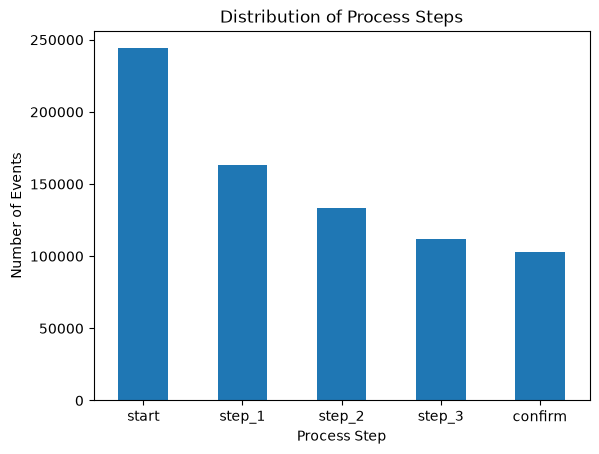

In [39]:
# Define the logical funnel order (not alphabetical)
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

step_counts.reindex(step_order).plot(kind='bar')
plt.title('Distribution of Process Steps')
plt.xlabel('Process Step')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.show()

In [57]:
# 2. Determine how events are ordered
# (assign a numeric order to each step so we can check sequencing later)

step_order_map = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}

df_web_data['step_order'] = df_web_data['process_step'].map(step_order_map)
df_web_data[['process_step', 'step_order']].drop_duplicates()

,process_step,step_order
0,step_3,3
1,step_2,2
6,step_1,1
7,start,0
8,confirm,4


In [41]:
# 3. Check whether timestamps are chronological within each visit 
# (for ex:  did the user move forward through the funnel in time order, or jump around?)

# Sort by visit and time first
df_sorted = df_web_data.sort_values(by=['visit_id', 'date_time'])

In [42]:
# For each visit, check if step_order INCREASES as time increases
# (a "reversal" means a later timestamp has a LOWER step number than the one before it in that same visit)

df_sorted['step_order_prev'] = df_sorted.groupby('visit_id')['step_order'].shift(1)
df_sorted['is_reversal'] = df_sorted['step_order'] < df_sorted['step_order_prev']

reversal_counts = df_sorted.groupby('visit_id')['is_reversal'].sum()
visits_with_reversals = reversal_counts[reversal_counts > 0]

print(f"Total visits: {df_sorted['visit_id'].nunique()}")
print(f"Visits with at least one out-of-order step: {len(visits_with_reversals)}")
print(f"Percentage: {len(visits_with_reversals) / df_sorted['visit_id'].nunique() * 100:.2f}%")

Total visits: 158095
Visits with at least one out-of-order step: 40516
Percentage: 25.63%


In [43]:
# an example of a visit with reversals (sanity-check what "out of order" actually looks like in real data)

example_visit_id = visits_with_reversals.index[0]

df_sorted[df_sorted['visit_id'] == example_visit_id][
    ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'step_order']
]

,client_id,visitor_id,visit_id,process_step,date_time,step_order
240562,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,0
240561,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,1
240560,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,2
240559,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:35,1
240558,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:41,1
240557,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:45,0
240556,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:59,0
240555,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:22:04,1
240554,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:22:08,2
240553,7338123,612065484_94198474375,100019538_17884295066_43909,step_3,2017-04-09 16:24:01,3


In [44]:
# 4. Check journey completeness (does each visit start at "start" and how far does it get?)
# The furthest step reached in each visit

furthest_step = df_sorted.groupby('visit_id')['step_order'].max()
furthest_step_label = furthest_step.map({v: k for k, v in step_order_map.items()})

print(furthest_step_label.value_counts())

step_order
confirm    89826
start      26846
step_3     15627
step_1     15354
step_2     10442
Name: count, dtype: int64


In [45]:
# 5. Identify incomplete journeys
# (visits that never reached "confirm")

furthest_step = df_sorted.groupby('visit_id')['step_order'].max()

incomplete_visits = furthest_step[furthest_step < step_order_map['confirm']]
complete_visits = furthest_step[furthest_step == step_order_map['confirm']]

print(f"Total visits: {furthest_step.shape[0]}")
print(f"Complete journeys (reached confirm): {len(complete_visits)}")
print(f"Incomplete journeys: {len(incomplete_visits)}")
print(f"Incomplete rate: {len(incomplete_visits) / furthest_step.shape[0] * 100:.2f}%")

# Breakdown of WHERE incomplete journeys dropped off
furthest_step_label = furthest_step.map({v: k for k, v in step_order_map.items()})
print(furthest_step_label.value_counts())

Total visits: 158095
Complete journeys (reached confirm): 89826
Incomplete journeys: 68269
Incomplete rate: 43.18%
step_order
confirm    89826
start      26846
step_3     15627
step_1     15354
step_2     10442
Name: count, dtype: int64


In [46]:
# 6. Investigate repeated events (same client + visit + step happening more than once)

repeated_events = df_sorted.groupby(
    ['visit_id', 'process_step']
).size().reset_index(name='event_count')

repeated_events = repeated_events[repeated_events['event_count'] > 1]

print(f"Visit/step combinations with repeats: {len(repeated_events)}")
print(repeated_events.sort_values('event_count', ascending=False).head(10))

# Which step gets repeated the most?
print(repeated_events.groupby('process_step')['event_count'].sum().sort_values(ascending=False))

Visit/step combinations with repeats: 124856
                            visit_id process_step  event_count
252877  512831152_67980938484_874337        start           48
476401  875138661_34710212496_881092       step_1           40
157429  356549486_83727228650_639957        start           33
365688  694918984_92465751580_342876        start           32
403359  756030933_38926415334_603627        start           32
399994  750305338_48716927227_197559        start           32
105708  273092462_14025162492_252779        start           32
256064   518285126_8572733997_709761        start           32
529721  961878360_85895454962_607105        start           32
332625   64174757_15836021608_382578        start           32
process_step
start      154158
step_1      73691
step_2      47697
step_3      29196
confirm     22102
Name: event_count, dtype: int64


In [47]:
# 7. Investigate multiple start events (a single visit logging "start" more than once)

start_counts = df_sorted[df_sorted['process_step'] == 'start'].groupby('visit_id').size()

multiple_starts = start_counts[start_counts > 1]
print(f"Visits with more than one 'start' event: {len(multiple_starts)}")
print(multiple_starts.sort_values(ascending=False).head(10))

# Look at an example
example_visit = multiple_starts.index[0]
df_sorted[df_sorted['visit_id'] == example_visit][
    ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']
]

Visits with more than one 'start' event: 55115
visit_id
512831152_67980938484_874337    48
356549486_83727228650_639957    33
518285126_8572733997_709761     32
756030933_38926415334_603627    32
750305338_48716927227_197559    32
273092462_14025162492_252779    32
961878360_85895454962_607105    32
308874104_3998249411_902973     32
694918984_92465751580_342876    32
64174757_15836021608_382578     32
dtype: int64


,client_id,visitor_id,visit_id,process_step,date_time
240562,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56
240561,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12
240560,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21
240559,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:35
240558,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:41
240557,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:45
240556,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:59
240555,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:22:04
240554,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:22:08
240553,7338123,612065484_94198474375,100019538_17884295066_43909,step_3,2017-04-09 16:24:01


In [48]:
# 8. Investigate multiple confirm events (a single visit logging "confirm" more than once)

confirm_counts = df_sorted[df_sorted['process_step'] == 'confirm'].groupby('visit_id').size()

multiple_confirms = confirm_counts[confirm_counts > 1]
print(f"Visits with more than one 'confirm' event: {len(multiple_confirms)}")
print(multiple_confirms.sort_values(ascending=False).head(10))

# Look at an example
example_visit = multiple_confirms.index[0]
df_sorted[df_sorted['visit_id'] == example_visit][
    ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']
]

Visits with more than one 'confirm' event: 8965
visit_id
115772476_64303792531_611679    16
875138661_34710212496_881092    16
817562193_57472961580_383121    16
435978514_20801260238_387838    15
51030400_49907048940_545931     13
155305468_93296256914_310722    11
757871028_15106530273_112760    10
575675483_34592408477_435173    10
273063204_82449693501_472072    10
591043729_42800968342_813719    10
dtype: int64


,client_id,visitor_id,visit_id,process_step,date_time
108614,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17
108613,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09


In [49]:
# 9. Summary table: pulling it all together

summary = pd.DataFrame({
    'metric': [
        'Total visits',
        'Complete journeys (reached confirm)',
        'Incomplete journeys',
        'Visits with repeated steps',
        'Visits with multiple starts',
        'Visits with multiple confirms'
    ],
    'count': [
        furthest_step.shape[0],
        len(complete_visits),
        len(incomplete_visits),
        repeated_events['visit_id'].nunique(),
        len(multiple_starts),
        len(multiple_confirms)
    ]
})
print(summary)

                                metric   count
0                         Total visits  158095
1  Complete journeys (reached confirm)   89826
2                  Incomplete journeys   68269
3           Visits with repeated steps   72542
4          Visits with multiple starts   55115
5        Visits with multiple confirms    8965


In [50]:
# 10. Investigate repeated process steps consecutive repeats — the same step logged
#  back-to-back within a visit, which is different from the same step appearing twice non-consecutively)

df_sorted['prev_step'] = df_sorted.groupby('visit_id')['process_step'].shift(1)
df_sorted['is_consecutive_repeat'] = df_sorted['process_step'] == df_sorted['prev_step']
print(f"Consecutive repeated steps: {df_sorted['is_consecutive_repeat'].sum()}")

# Which step is repeated back-to-back the most?
print(df_sorted[df_sorted['is_consecutive_repeat']]['process_step'].value_counts())


Consecutive repeated steps: 87980
process_step
start      59865
confirm    12266
step_1      7748
step_3      4292
step_2      3809
Name: count, dtype: int64


In [51]:
# Example
example_visit = df_sorted[df_sorted['is_consecutive_repeat']]['visit_id'].iloc[0]
df_sorted[df_sorted['visit_id'] == example_visit][
    ['client_id', 'visit_id', 'process_step', 'date_time']
]

,client_id,visit_id,process_step,date_time
108614,3561384,100012776_37918976071_457913,confirm,2017-04-26 13:22:17
108613,3561384,100012776_37918976071_457913,confirm,2017-04-26 13:23:09


In [52]:
# 11. Investigate backward navigation (a later timestamp has a LOWER step number than the
#  previous event in the same visit -> user moved backward)

df_sorted['step_order_prev'] = df_sorted.groupby('visit_id')['step_order'].shift(1)
df_sorted['is_backward'] = df_sorted['step_order'] < df_sorted['step_order_prev']
backward_counts = df_sorted.groupby('visit_id')['is_backward'].sum()
visits_with_backward = backward_counts[backward_counts > 0]

print(f"Visits with backward navigation: {len(visits_with_backward)}")
print(f"Percentage of all visits: {len(visits_with_backward) / df_sorted['visit_id'].nunique() * 100:.2f}%")


# Which step transitions go backward the most? (e.g. step_3 -> step_2)
backward_transitions = df_sorted[df_sorted['is_backward']].copy()
backward_transitions['transition'] = (
    backward_transitions['prev_step'] + ' -> ' + backward_transitions['process_step']
)
print(backward_transitions['transition'].value_counts())


Visits with backward navigation: 40516
Percentage of all visits: 25.63%
transition
step_1 -> start      23630
step_2 -> step_1     12178
step_3 -> step_2      9430
step_3 -> start       8286
step_2 -> start       5948
confirm -> start      1944
step_3 -> step_1      1639
confirm -> step_1      559
confirm -> step_3      257
confirm -> step_2        7
Name: count, dtype: int64


In [53]:
# 12. Investigate unusually long sessions (both by TIME duration and by EVENT count)

# Session duration in minutes (first to last event per visit)
session_duration = df_sorted.groupby('visit_id')['date_time'].agg(['min', 'max'])
session_duration['duration_minutes'] = (
    session_duration['max'] - session_duration['min']
).dt.total_seconds() / 60

print(session_duration['duration_minutes'].describe())

count    158095.000000
mean          5.294590
std           9.943423
min           0.000000
25%           0.700000
50%           2.850000
75%           6.033333
max         712.800000
Name: duration_minutes, dtype: float64


In [54]:
# Flag outliers using the IQR method

Q1 = session_duration['duration_minutes'].quantile(0.25)
Q3 = session_duration['duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
long_sessions = session_duration[session_duration['duration_minutes'] > upper_bound]

print(f"Upper bound for 'normal' session length: {upper_bound:.2f} minutes")
print(f"Unusually long sessions: {len(long_sessions)}")
print(long_sessions.sort_values('duration_minutes', ascending=False).head(10))

Upper bound for 'normal' session length: 14.03 minutes
Unusually long sessions: 12554
                                             min                 max  \
visit_id                                                               
591043729_42800968342_813719 2017-06-01 19:56:18 2017-06-02 07:49:06   
831987489_84761163210_335684 2017-04-09 23:34:50 2017-04-10 11:14:15   
925945662_35081527962_992814 2017-05-18 22:29:08 2017-05-19 07:35:06   
478417687_30092205462_548423 2017-05-17 15:49:37 2017-05-18 00:36:41   
483738263_4057680487_61869   2017-06-08 12:06:55 2017-06-08 18:28:30   
501042989_50588313479_700675 2017-04-12 11:06:37 2017-04-12 16:06:52   
487574707_93479825574_193980 2017-05-30 17:09:11 2017-05-30 21:54:48   
513201671_3130566235_253600  2017-05-24 12:28:56 2017-05-24 17:13:37   
588904389_16165570985_286826 2017-06-03 08:52:25 2017-06-03 13:36:57   
391696103_92230204739_479887 2017-04-15 11:03:39 2017-04-15 15:45:20   

                              duration_minutes  


In [55]:
# Unusually long sessions by EVENT COUNT (not just time)

visit_event_counts = df_sorted.groupby('visit_id').size()

print(visit_event_counts.describe())

Q1_e = visit_event_counts.quantile(0.25)
Q3_e = visit_event_counts.quantile(0.75)
IQR_e = Q3_e - Q1_e
upper_bound_e = Q3_e + 1.5 * IQR_e
long_event_sessions = visit_event_counts[visit_event_counts > upper_bound_e]

print(f"Upper bound for 'normal' event count: {upper_bound_e:.2f}")
print(f"Sessions with unusually many events: {len(long_event_sessions)}")
print(long_event_sessions.sort_values(ascending=False).head(10))

count    158095.000000
mean          4.778171
std           2.988947
min           1.000000
25%           2.000000
50%           5.000000
75%           6.000000
max         104.000000
dtype: float64
Upper bound for 'normal' event count: 12.00
Sessions with unusually many events: 2945
visit_id
875138661_34710212496_881092    104
518285126_8572733997_709761      88
602953935_48759866176_238903     80
961878360_85895454962_607105     80
416293838_23892754049_547527     72
308874104_3998249411_902973      72
694918984_92465751580_342876     64
712824876_8175482950_365042      61
51853936_4251561986_994623       56
117873258_70126577862_733345     56
dtype: int64


In [56]:
# Summary table

summary2 = pd.DataFrame({
    'metric': [
        'Consecutive repeated steps',
        'Visits with backward navigation',
        'Unusually long sessions (by duration)',
        'Unusually long sessions (by event count)'
    ],
    'count': [
        df_sorted['is_consecutive_repeat'].sum(),
        len(visits_with_backward),
        len(long_sessions),
        len(long_event_sessions)
    ]
})
print(summary2)



                                     metric  count
0                Consecutive repeated steps  87980
1           Visits with backward navigation  40516
2     Unusually long sessions (by duration)  12554
3  Unusually long sessions (by event count)   2945


Finding : 
metric   count
0                         Total visits  158095
1  Complete journeys (reached confirm)   89826
2                  Incomplete journeys   68269
3           Visits with repeated steps   72542
4          Visits with multiple starts   55115
5        Visits with multiple confirms    8965

metric  count
0                Consecutive repeated steps  87980
1           Visits with backward navigation  40516
2     Unusually long sessions (by duration)  12554
3  Unusually long sessions (by event count)   2945

Duplicates data: 10,764 rows are exact duplicates, and a much larger 319,806 rows belong to visit/step combinations that repeat(e.g. the same step logged multiple times seconds apart).
The visit_id → visitor_id link is perfectly clean (0 violations) — every visit belongs to exactly one visitor, as expected.
The visitor_id → client_id link is not perfect: 1,645 visitor_id are associated with more than one client_id.
It's normal and expected for one client to have multiple visitor_ids or multiple visits (9,773 and 27,861 clients respectively).
22,484 visits (~14%) have only a single event logged.
Over half of visits (56.8%) reach "confirm".
Roughly 46% of visits have repeated steps, and ~26% include backward navigation. 
A relatively small share of visits are outliers by duration (7.9%) or event count (1.9%).